# Determinación de Volúmenes de estimación

Nuestro **objetivo** es determinar el volumen espacial que sera el limite de estimación para cada una de las Unidades Geológicas. Es decir, la estimación realizada con la información perteneciente a cada unidad geológica definida no rebasara mas allá de los limites representados por este volumen .


Nuestro punto de partida sera la base de datos simplificada de la sección anterior.

In [14]:
## Cargar data simplificada de la sección anterior

import pandas as pd
import numpy as np

# Cargar base de datos en pandas
df = pd.read_csv('data.csv', sep=',', encoding='latin1')
df

,X,Y,Z,cu_pct,UG
0,472187.343570,6.925806e+06,4211.772172,0.020300,2.0
1,472187.740701,6.925807e+06,4205.844155,0.009500,2.0
2,472188.089349,6.925807e+06,4199.915106,0.006767,2.0
3,472188.470072,6.925808e+06,4193.995578,0.010433,2.0
4,472188.878860,6.925809e+06,4188.084383,0.011133,2.0
...,...,...,...,...,...
16877,471922.691912,6.925392e+06,4022.517796,0.095000,4.0
16878,471924.631624,6.925395e+06,4017.651413,0.109000,4.0
16879,471926.586648,6.925397e+06,4012.784519,0.179667,4.0
16880,471928.548677,6.925400e+06,4007.918137,0.148333,4.0


## Kriging de indicadores

Para la determinación de cada volumen de estimación, emplearemos la técnica llamada Kriging de Indicadores.

### Formalismo de indicadores

A continuación, usamos métodos indicadores para estimar una variable categórica en el espacio.

Si $i(\bf{u}; z_k)$ es un indicador para una variable categórica $z$ (como es el caso de la variable UG), definida como

$$
i(\bf{u}; z_k) =
\begin{cases} 
    1, & \text{si } Z(\bf{u}) = z_k \\
    0, & \text{si } Z(\bf{u}) \ne z_k 
\end{cases}
$$

![](../../_static/ind1.png "")


entonces la probabilidad de que encontrar esta categoría lejos de las posiciones de nuestra data debería ser igual a la proporción de esta categoría en nuestra base de datos (por la hipótesis de estacionariedad)


por ejemplo, 

* dado la categoria UG = 2, $z_2 = 2$, y dato en $\bf{u}_1$, $z(\bf{u}_1) = 2$, entonces $i(\bf{u}_1; z_2) = 1$
* dado la categoria, $z_1 = 1$, con una proporción en nuestra base de datos de 33.33%, y una variable aleatorea (VA) categorica lejos de los datos, $Z(\bf{u})$, entonces la probabilidad de que la VA tome el valor $z_1$ es igual a $0.333$.

#### Variograma indicador

Los variogramas se calculan y modelan a partir de la transformación indicadora de los datos espaciales y se usan para el kriging de indicadores. El variograma indicador es,

$$
\gamma_i(\mathbf{h}; z_k) = \frac{1}{2N(\mathbf{h})} 
\sum_{\alpha=1}^{N(\mathbf{h})} 
\left[ i(\mathbf{u}_\alpha; z_k) - i(\mathbf{u}_\alpha + \mathbf{h}; z_k) \right]^2
$$

donde $i(\mathbf{u}_\alpha; z_k)$ e $i(\mathbf{u}_\alpha + \mathbf{h}; z_k)$ son las transformaciones indicadoras para la categoría $z_k$ en la posición de cola $\mathbf{u}_\alpha$ y en la posición de cabeza $\mathbf{u}_\alpha + \mathbf{h}$ respectivamente. 

* notar que la transformación indicadora $i(\bf{u},z_k)$ es o bien 0 o bien 1, en cuyo caso $\left[ i(\mathbf{u}_\alpha; z_k) - i(\mathbf{u}_\alpha + \mathbf{h}; z_k) \right]^2$ es igual a 0 cuando los valores en cabeza y cola pertenecen a la misma categoría $ z_k$, o 1 cuando son diferentes.

* la meseta (sill) de un variograma indicador es la varianza indicadora calculada como,

$$
\sigma_i^2 = p \cdot (1 - p)
$$ 

donde $p$ es la proporción de 1's (o de ceros, ya que la función es simétrica respecto a la proporción)


#### Kriging de indicadores

La aplicación de kriging simple a un conjunto indicadores, una por cada categoría para características categóricas, define directamente un modelo de probabilidad local de una cierta categoría en una ubicación desconocida, $\bf{u}$, a partir de nuestros datos.

El estimador de kriging de indicadores se define como,

$$
p^*_{IK}(\mathbf{u}; k) =
\sum_{\alpha=1}^n \lambda_\alpha(k) \cdot i(\mathbf{u}_\alpha; k) 
+ \left( 1 - \sum_{\alpha=1}^n \lambda_\alpha(k) \right) \cdot p(k)
$$

donde $\lambda_\alpha(k)$ es el peso de kriging indicador para el dato $\alpha$ y la categoría $k$, $i(\mathbf{u}_\alpha; k)$ es la transformación indicadora de la categoría $k$ del dato en la ubicación $\mathbf{u}_\alpha$ y $p(k)$ la probabilidad categórica.

Los pasos para el kriging de indicadores son,

1. Establecer una serie de categorías. En nuestro caso, estas ya fueron definidas en los capítulos anteriores.

2. Aplicar la transformación indicadora a los datos.

3. Calcular el *variograma indicador* a partir de la transformación indicadora de los datos para cada categoría.

4. Aplicar kriging de indicadores para estimar la probabilidad acumulada para características continuas o la probabilidad para características categóricas en una ubicación no muestreada, usando el variograma indicador para cada categoría.

Comentario general,

* se necesita un modelo de variograma para cada categoría; por lo tanto, es un problema de inferencia difícil.


#### Cargar las bibliotecas requeridas

El siguiente código carga las bibliotecas requeridas.

In [ ]:
#### Instalar libreria de geoestadistica Geostatspy
!pip install geostatspy

In [ ]:
import geostatspy.GSLIB as GSLIB                              # GSLIB utilities, visualization and wrapper
import geostatspy.geostats as geostats                        # GSLIB methods convert to Python      
import geostatspy
print('GeostatsPy version: ' + str(geostatspy.__version__))  

import os                                                     # set working directory, run executables

from tqdm import tqdm                                         # suppress the status bar
from functools import partialmethod
tqdm.__init__ = partialmethod(tqdm.__init__, disable=True)

ignore_warnings = True                                        # ignore warnings?
import numpy as np                                            # ndarrays for gridded data
import pandas as pd                                           # DataFrames for tabular data
import matplotlib.pyplot as plt                               # for plotting
import matplotlib as mpl                                      # custom colorbar
import matplotlib.ticker as mticker                           # custom colorpar ticks
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator) # control of axes ticks
plt.rc('axes', axisbelow=True)                                # plot all grids below the plot elements
if ignore_warnings == True:                                   
    import warnings
    warnings.filterwarnings('ignore')
cmap = plt.cm.inferno   



GeostatsPy version: 0.0.78


### Proporciones de cada UG en nuestra base de datos

Verificamos la proporción de cada UG en nuestra base de datos. (Para este ejemplo solo consideramos las UGs 2, 3 y 4.)

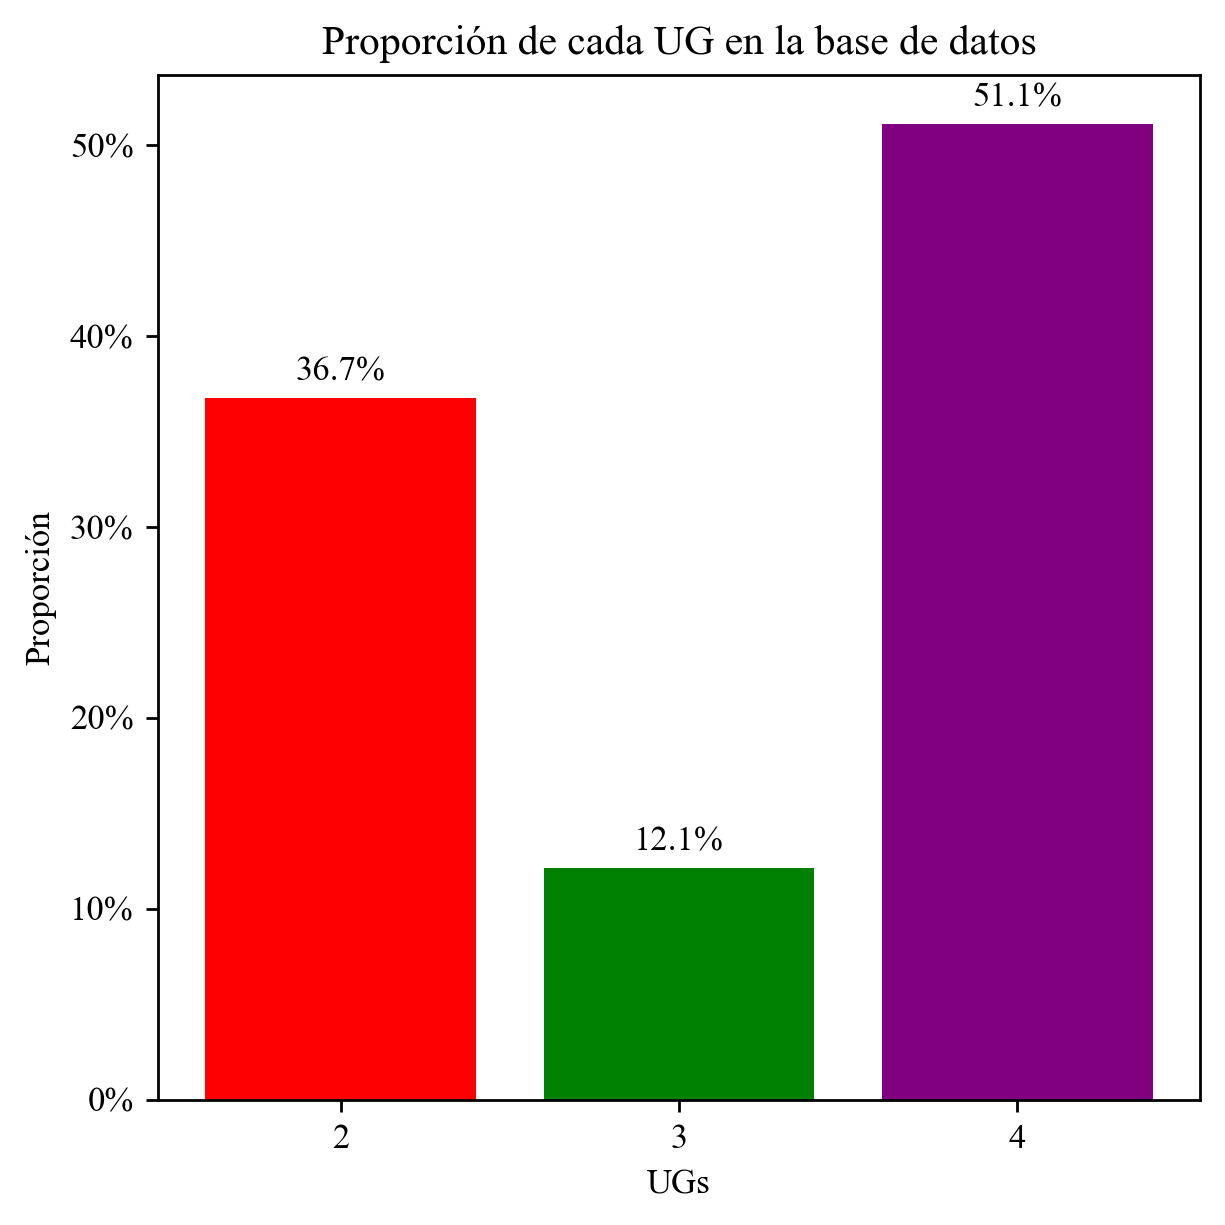

In [59]:
fig, ax = plt.subplots(figsize=(5,5))
ax.clear()

plt.rcParams['figure.dpi'] = 250 # Setear resolución de la figura
plt.rcParams["font.family"] = "Times New Roman"

# Proporciones de cada UG en nuestra base de datos
color = ['red','green','purple']

proportions = df['UG'].value_counts(normalize=True).sort_index()
labels = proportions.index.astype(int).astype(str)

bars = ax.bar(labels, proportions.values, color=color[:len(proportions)])
ax.set_title('Proporción de cada UG en la base de datos')
ax.set_xlabel('UGs')
ax.set_ylabel('Proporción')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

for bar, p in zip(bars, proportions.values):
    ax.annotate(f"{p*100:.1f}%", xy=(bar.get_x() + bar.get_width() / 2, p),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

fig.tight_layout()
plt.show()

### Codificar base de datos en funcion de indicadores

Convendrá agregar a nuestra base de datos 3 columnas nuevas que codifiquen la variable indicador para cada UG

In [66]:
# Agregar columnas de indicadores para cada UG

df['indicador UG_2'] = np.where(df['UG'] == 2, 1, 0)
df['indicador UG_3'] = np.where(df['UG'] == 3, 1, 0)
df['indicador UG_4'] = np.where(df['UG'] == 4, 1, 0)

df

,X,Y,Z,cu_pct,UG,UGs,indicador UG_2,indicador UG_3,indicador UG_4
0,472187.343570,6.925806e+06,4211.772172,0.020300,2.0,4,1,0,0
1,472187.740701,6.925807e+06,4205.844155,0.009500,2.0,4,1,0,0
2,472188.089349,6.925807e+06,4199.915106,0.006767,2.0,4,1,0,0
3,472188.470072,6.925808e+06,4193.995578,0.010433,2.0,4,1,0,0
4,472188.878860,6.925809e+06,4188.084383,0.011133,2.0,4,1,0,0
...,...,...,...,...,...,...,...,...,...
16877,471922.691912,6.925392e+06,4022.517796,0.095000,4.0,4,0,0,1
16878,471924.631624,6.925395e+06,4017.651413,0.109000,4.0,4,0,0,1
16879,471926.586648,6.925397e+06,4012.784519,0.179667,4.0,4,0,0,1
16880,471928.548677,6.925400e+06,4007.918137,0.148333,4.0,4,0,0,1


Podemos, en base a esta información, calcular la media de los indicadores (igual a la proporción) y la varianza.

In [83]:
#   calcular la media de los indicadores (igual a la proporcion) y la varianza.
mean_UG2 = df['indicador UG_2'].mean()
var_UG2 = df['indicador UG_2'].var()
mean_UG3 = df['indicador UG_3'].mean()
var_UG3 = df['indicador UG_3'].var()
mean_UG4 = df['indicador UG_4'].mean()
var_UG4 = df['indicador UG_4'].var()

print(f"UG2 - Media: {mean_UG2:.2f}, Varianza: {var_UG2:.2f}")
print(f"UG3 - Media: {mean_UG3:.2f}, Varianza: {var_UG3:.2f}")
print(f"UG4 - Media: {mean_UG4:.2f}, Varianza: {var_UG4:.2f}")

UG2 - Media: 0.37, Varianza: 0.23
UG3 - Media: 0.12, Varianza: 0.11
UG4 - Media: 0.51, Varianza: 0.25


## Variograma experimental de indicadores

#### Cálculo experimental del variograma

Veamos los parámetros de la función **gamv** para datos irregulares, la función experimental de GeostatsPy para el cálculo de variogramas.

In [86]:
geostats.gamv  # ver parametros de la función gamv

<function geostatspy.geostats.gamv(df, xcol, ycol, vcol, tmin, tmax, xlag, xltol, nlag, azm, atol, bandwh, isill)>

Estamos listos para calcular los variogramas. Vamos a calcular variogramas isótropos para todas las UGs. Algunas notas sobre los parámetros que elegí:

In [84]:
tmin = -9999.; tmax = 9999.; 
lag_dist = 50.0; lag_tol = 25.0; nlag = 10; bandh = 9999.9; azi = 0; atol = 90.0; isill = 0

* tmin, tmax son límites de recorte — establecidos para no tener impacto, no es necesario filtrar los datos.
* lag_dist, lag_tol son la distancia de lag y la tolerancia de lag — definidos según el espaciado común de los datos (50 m) y con una tolerancia del 50% de la distancia de lag para un mayor suavizado.
* nlag es el número de lags — definido para extenderse un poco más allá del 50% del rango de los datos.
* bandh es el ancho de banda horizontal — configurado para no tener efecto.
* azi es el acimut — no tiene efecto porque hemos fijado atol (tolerancia de acimut) en 90.0.
* isill es un indicador para estandarizar la distribución a varianza 1 — no será usado durante este curso.

Probemos estos parámetros y visualicemos los resultados.

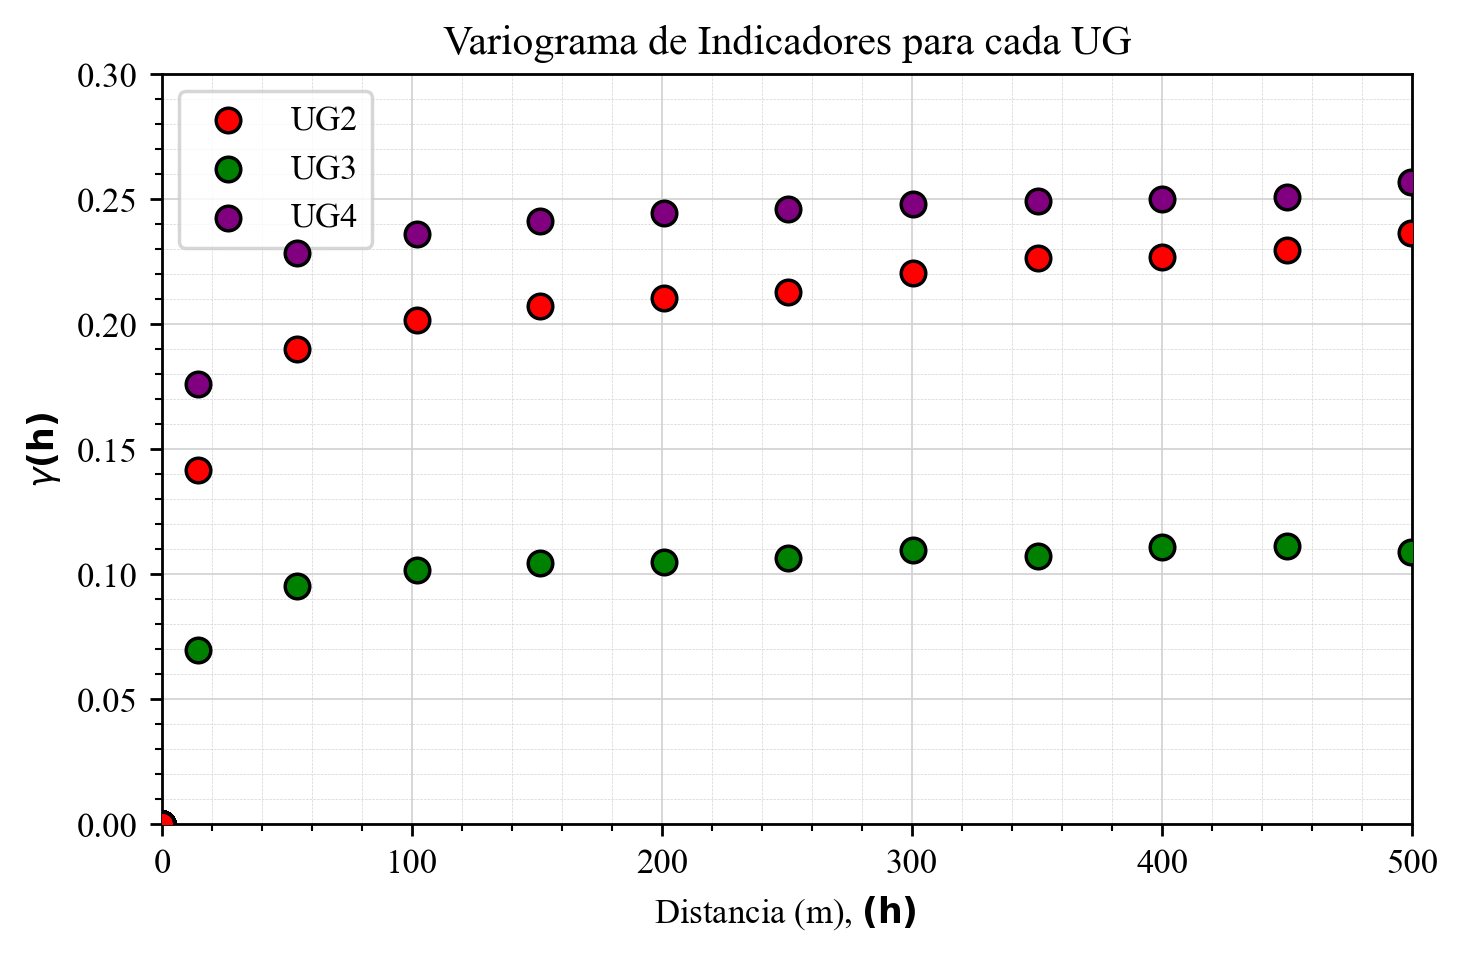

In [143]:
lag, UG2_gamma, UG2_npair = geostats.gamv(df,"X","Y","indicador UG_2",tmin,tmax,lag_dist,lag_tol,nlag,azi,atol,
            bandh,isill)
lag, UG3_gamma, UG3_npair = geostats.gamv(df,"X","Y","indicador UG_3",tmin,tmax,lag_dist,lag_tol,nlag,azi,atol,
            bandh,isill)
lag, UG4_gamma, UG4_npair = geostats.gamv(df,"X","Y","indicador UG_4",tmin,tmax,lag_dist,lag_tol,nlag,azi,atol,
            bandh,isill)

fig, ax = plt.subplots(figsize=(5,2.5))
ax.clear()

plt.rcParams['figure.dpi'] = 250 # Setear resolución de la figura
plt.rcParams["font.family"] = "Times New Roman"

plt.scatter(lag,UG2_gamma,color = 'red',edgecolor='black',s=50,marker='o',label = 'UG2',zorder=10)
plt.scatter(lag,UG3_gamma,color = 'green',edgecolor='black',s=50,marker='o',label = 'UG3',zorder=9)
plt.scatter(lag,UG4_gamma,color = 'purple',edgecolor='black',s=50,marker='o',label = 'UG4',zorder=8)

plt.xlabel(r'Distancia (m), $\bf(h)$ '); plt.ylabel(r'$\gamma \bf(h)$')
plt.title('Variograma de Indicadores para cada UG')
plt.xlim([0,500]); plt.ylim([0,.3]); plt.legend(loc='upper left');

## add grid lines
plt.grid(visible=True, which='major', color='lightgrey', linestyle='-', linewidth=0.5)
plt.grid(visible=True, which='minor', color='lightgrey', linestyle='--', linewidth=0.2)
plt.minorticks_on()


plt.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.2, wspace=0.2, hspace=0.3)
plt.show()

Nota: hemos escalado el tamaño de los puntos según el número relativo de pares.

- Los puntos pequeños tienen menos pares de datos; por lo tanto, son menos confiables.

Construyamos un modelo razonable hasta la meseta (sill).

## Modelado del variograma


Usamos la función make_variogram de GeostatsPy para construir un objeto modelo de variograma.

- Es un diccionario para almacenar de forma compacta los parámetros del modelo de variograma que se usan en la visualización, kriging y simulación.

Los parámetros del modelo de variograma incluyen:

- **nug** - aporte del efecto pepita (nugget) a la meseta (sill)
- **nst** - número de estructuras anidadas (1 o 2)
- **it** - tipo para la estructura (1 - esférico, 2 - exponencial, 3 - gaussiano)
- **cc** - contribución de cada estructura anidada (las contribuciones + nugget deben sumar la meseta)
- **azi** - acimut para esta estructura (dirección mayor), la minor es ortogonal
- **hmaj** - alcance en la dirección mayor
- **hmin** - alcance en la dirección menor

Usamos arreglos para it, cc, azi, hmaj y hmin cuando hay más de una estructura anidada.

- Si solo usamos 1 estructura (más opción de nugget), omita los parámetros de la segunda estructura y estos por defecto serán $cc2 = 0$ (sin contribución).

Tomemos como ejemplo la UG 2. Aquí está mi modelo:

In [154]:
nug = 0.12; nst = 1     # definimos el efecto pepa (0.12) y el número de estructuras anidadas (1)
it1 = 2; cc1 = (var_UG2 - nug); azi1 = 45; hmaj1 = 200; hmin1 = hmaj1   # 1 estructura anidada (exponencial)

vario_UG2 = GSLIB.make_variogram(nug,nst,it1,cc1,azi1,hmaj1,hmin1) # crear el objeto del modelo de variograma

 make_variogram Warning: sill does not sum to 1.0, do not use in simulation 


No considerar aviso, el cual nos indica que la suma de las mesetas no suma 1.0 (precaviendo en el caso de variables con varianza estandarizada igual a 1)

#### Trazado del modelo de variograma

Para trazar el variograma usamos la función `vmodel` de GeostatsPy que proyecta el modelo a un conjunto de distancias de lag en las direcciones mayor y menor.

Las entradas para `vmodel` son:

- **nlag** - número de puntos a lo largo del variograma para la proyección
- **xlag** - tamaño del lag para la proyección
- **azm** - dirección de la proyección en azimut (trabajamos en 2D)
- **vario** - el diccionario del modelo de variograma creado con `make_variogram`

Nota: esta función es solo para visualización; por eso es habitual usar un **xlag** muy pequeño y un **nlag** grande para una visualización de alta resolución del modelo.

Las salidas de `vmodel` incluyen:

- **index** - número de lag para la proyección
- **lag distance** - distancia offset a lo largo de la proyección (el $\mathbf{h}$ en el gráfico)
- **variogram** - valor del variograma en esa distancia de lag (el $\gamma(\mathbf{h})$)
- **covariance function** - la función de covarianza asociada
- **correlogram** - el correlograma para la distancia de lag (para $\rho(\mathbf{h})$)

Tenemos 1 estructura y con efecto pepa como ejemplo para el caso de la UG 2.  

 x,y,z offsets = 0.0,10.0


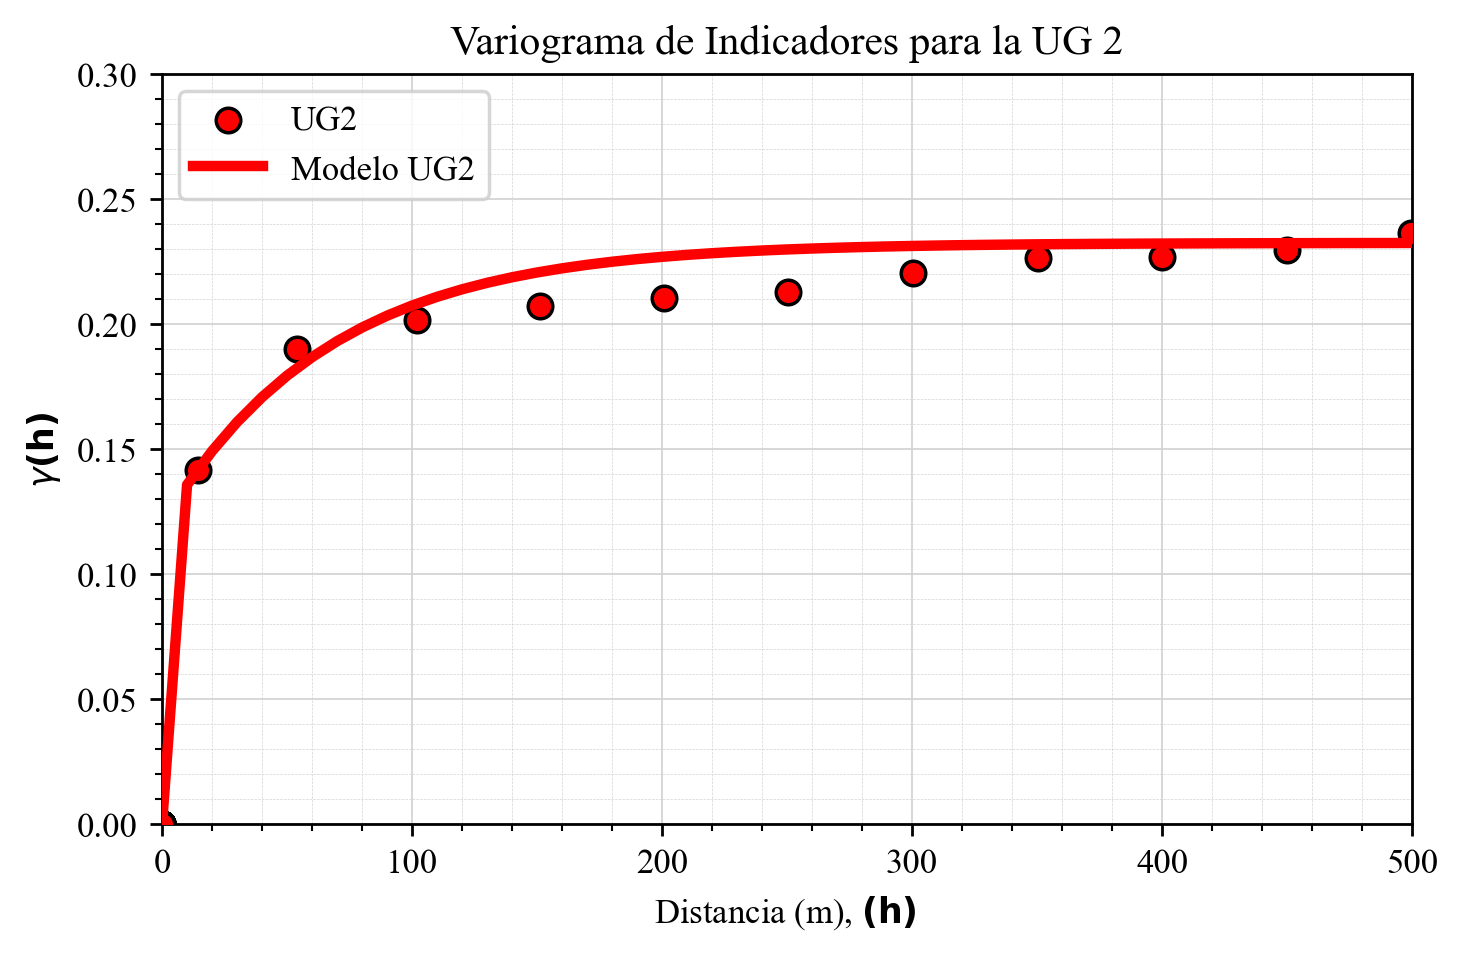

In [155]:
nlag = 100; xlag = 10; azm = 0 # project the model in 0 azimuth
index,h_UG2,gam_UG2,cov,ro = geostats.vmodel(nlag,xlag,azm,vario_UG2)

fig, ax = plt.subplots(figsize=(5,2.5))
ax.clear()

plt.rcParams['figure.dpi'] = 250 # Setear resolución de la figura
plt.rcParams["font.family"] = "Times New Roman"

plt.scatter(lag,UG2_gamma,color = 'red',edgecolor='black',s=50,marker='o',label = 'UG2',zorder=10)

plt.plot(h_UG2,gam_UG2,color='red',lw=3,zorder=100,label = 'Modelo UG2')

plt.xlabel(r'Distancia (m), $\bf(h)$ '); plt.ylabel(r'$\gamma \bf(h)$')
plt.title('Variograma de Indicadores para la UG 2')
plt.xlim([0,500]); plt.ylim([0,.3]); plt.legend(loc='upper left');

## add grid lines
plt.grid(visible=True, which='major', color='lightgrey', linestyle='-', linewidth=0.5)
plt.grid(visible=True, which='minor', color='lightgrey', linestyle='--', linewidth=0.2)
plt.minorticks_on()

plt.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.2, wspace=0.2, hspace=0.3)
plt.show()

Se ve bastante bien; recuerde que solo modelamos hasta la meseta (sill) y no por encima de ella.

Ahora modelamos los variogramas para el resto de las categorías.

 make_variogram Warning: sill does not sum to 1.0, do not use in simulation 
 x,y,z offsets = 0.0,10.0
 make_variogram Warning: sill does not sum to 1.0, do not use in simulation 
 x,y,z offsets = 0.0,10.0


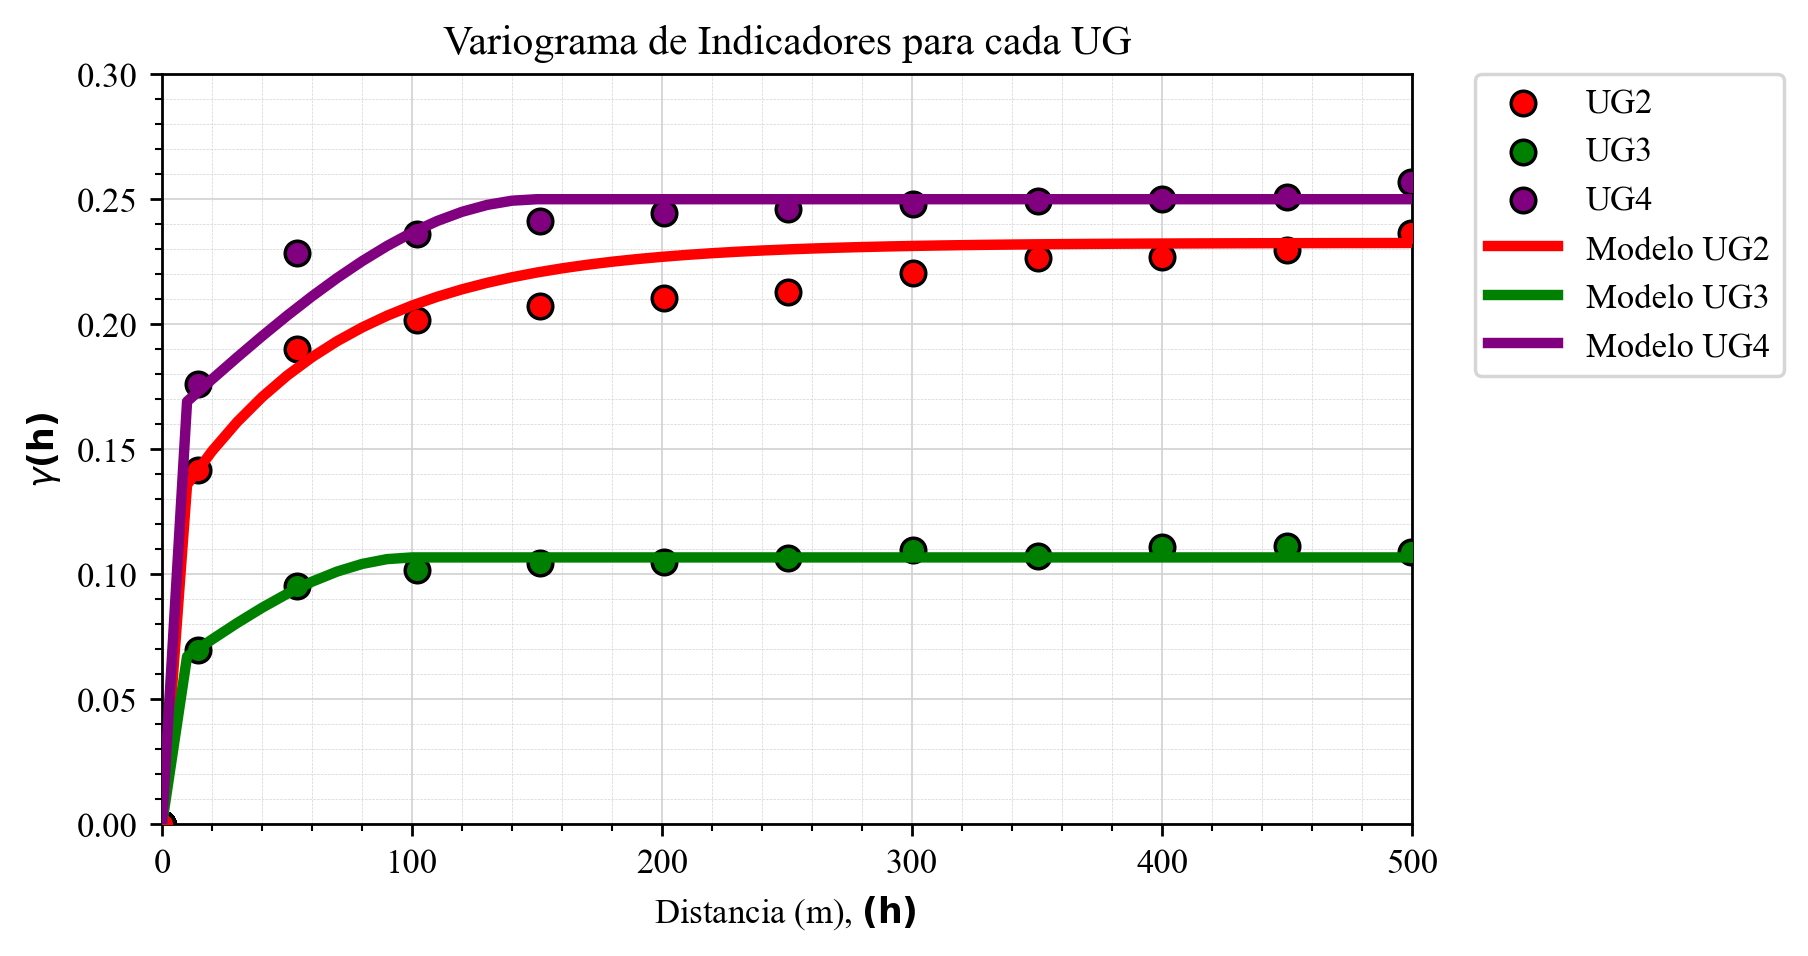

In [156]:
nug = 0.06; nst = 1                                             # Variograma para UG 3 (verde)
it1 = 1; cc1 = (var_UG3 - nug); azi1 = 0; hmaj1 = 100; hmin1 = hmaj1

vario_UG3 = GSLIB.make_variogram(nug,nst,it1,cc1,azi1,hmaj1,hmin1) # crear objeto variograma modelado

index,h_UG3,gam_UG3,cov,ro = geostats.vmodel(nlag,xlag,azm,vario_UG3)

nug = 0.16; nst = 1                                             # Variograma para UG 4 (morado)
it1 = 1; cc1 = (var_UG4 - nug); azi1 = 0; hmaj1 = 150; hmin1 = hmaj1

vario_UG4 = GSLIB.make_variogram(nug,nst,it1,cc1,azi1,hmaj1,hmin1) # crear objeto variograma modelado

index45,h_UG4,gam_UG4,cov,ro = geostats.vmodel(nlag,xlag,azm,vario_UG4)

fig, ax = plt.subplots(figsize=(5,2.5))     # Plotear todos los variogramas juntos
ax.clear()

plt.rcParams['figure.dpi'] = 250 # Setear resolución de la figura
plt.rcParams["font.family"] = "Times New Roman"

plt.scatter(lag,UG2_gamma,color = 'red',edgecolor='black',s=50,marker='o',label = 'UG2',zorder=10)
plt.scatter(lag,UG3_gamma,color = 'green',edgecolor='black',s=50,marker='o',label = 'UG3',zorder=9)
plt.scatter(lag,UG4_gamma,color = 'purple',edgecolor='black',s=50,marker='o',label = 'UG4',zorder=8)

plt.plot(h_UG2,gam_UG2,color='red',lw=3,zorder=100,label = 'Modelo UG2')
plt.plot(h_UG3,gam_UG3,color='green',lw=3,zorder=100,label = 'Modelo UG3')
plt.plot(h_UG4,gam_UG4,color='purple',lw=3,zorder=100,label = 'Modelo UG4')

plt.xlabel(r'Distancia (m), $\bf(h)$ '); plt.ylabel(r'$\gamma \bf(h)$')
plt.title('Variograma de Indicadores para cada UG')
plt.xlim([0,500]); plt.ylim([0,.3]); plt.legend(loc='upper left');

## add grid lines
plt.grid(visible=True, which='major', color='lightgrey', linestyle='-', linewidth=0.5)
plt.grid(visible=True, which='minor', color='lightgrey', linestyle='--', linewidth=0.2)
plt.minorticks_on()

# mover legenda fuera del plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.2, wspace=0.2, hspace=0.3)
plt.show()